# Exercise 5: Variational Auto Encoder
## Submission date: 08\06\2026, 23:59.

Submitted by:

 **Student 1 Name+ID

 **Student 2 Name+ID

<font color='red'>Before submission, please make sure that all the plots and results are present as a colab notebook file</font>


## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [1]:
## Standard libraries
import os
import math
import numpy as np
import pandas as pd
from collections import defaultdict

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
from IPython.display import set_matplotlib_formats
%config InlineBackend.figure_formats = ['svg', 'pdf']
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

Using device cuda:0


<Figure size 640x480 with 0 Axes>

In [2]:
# Transformations applied on each image => only make them a tensor
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 255.0 + torch.rand_like(x)) / 256.0)
])


# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]

Train size: 50000
Validation size: 10000
Test size: 10000


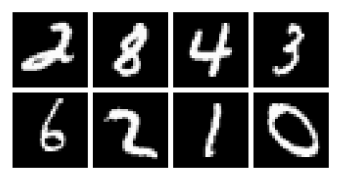

In [3]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=1)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import defaultdict
from torch.distributions import Normal, Independent

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class VAE(nn.Module):
    def __init__(self, latent_dim,recon_var):
        super().__init__()
        self.latent_dim = latent_dim
        self.logs = defaultdict(list)
        self.recon_var = recon_var

        # Encoder
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28 -> 14
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 14 -> 7
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 7 -> 4 (floor)
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Flatten()
        )

        # Compute shape after CNN
        dummy_input = torch.zeros(1, 1, 28, 28)
        conv_out_dim = self.encoder_cnn(dummy_input).shape[1]

        self.encoder_fc = nn.Sequential(
            nn.Linear(conv_out_dim, 256),
            nn.ReLU()
        )
        self.fc_mean = nn.Linear(256, latent_dim)
        self.fc_logstd = nn.Linear(256, latent_dim)

        # Decoder
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, conv_out_dim),
            nn.ReLU()
        )

        self.decoder_deconv = nn.Sequential(
            nn.Unflatten(1, (128, 4, 4)),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),  # 4 -> 7
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7 -> 14
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1, output_padding=0),  # 14 -> 28
            nn.Sigmoid(),  # Output between 0 and 1
        )

    def encode(self, x):
        h = self.encoder_cnn(x)
        h = self.encoder_fc(h)
        mu = self.fc_mean(h)
        logstd = self.fc_logstd(h)
        std = torch.exp(logstd)
        return mu, std

    def decode(self, z):
        h = self.decoder_fc(z)
        x_hat = self.decoder_deconv(h)
        return x_hat

    def sample_from_latent(self, mu, std):
        q = Normal(mu, std)
        z = q.rsample()  # reparameterization trick
        return z, q

    def calc_elbo(self, x):
        mu, std = self.encode(x)
        z, q = self.sample_from_latent(mu, std)

        x_hat = self.decode(z)

        # Reconstruction loss (Gaussian log-likelihood)
        rec_loss = F.mse_loss(x_hat, x, reduction='none')
        rec_loss = rec_loss.view(x.size(0), -1).sum(dim=1)
        rec_loss = rec_loss / (2 * self.recon_var**2)
        rec_loss = rec_loss.mean()

        # KL divergence with standard normal prior
        p = Normal(torch.zeros_like(mu), torch.ones_like(std))
        KLD = torch.distributions.kl_divergence(q, p).sum(dim=1).mean()

        # ELBO = - (reconstruction loss + KLD)
        elbo = rec_loss + KLD
        return elbo, rec_loss, KLD

    def log(self, key, value):
        self.logs[key].append(value)

    def training_step(self, batch):
        imgs, _ = batch
        imgs = imgs.to(device)
        loss, rec_loss, KLD = self.calc_elbo(imgs)
        self.log('train_elbo', loss.item())
        self.log('train_recon', rec_loss.item())
        self.log('train_KLD', KLD.item())
        return loss, rec_loss, KLD

    @torch.no_grad()
    def validation_step(self, loader):
        loss_obj = []
        for imgs, _ in tqdm(loader, leave=False):
            imgs = imgs.to(device)
            loss_obj.append(torch.tensor(self.calc_elbo(imgs)))

        loss_obj = torch.stack(loss_obj)
        loss, rec_loss, KLD = loss_obj.mean(dim=0)
        self.log('val_elbo', loss.item())
        self.log('val_recon', rec_loss.item())
        self.log('val_KLD', KLD.item())
        return loss, rec_loss, KLD

    @torch.no_grad()
    def test_step(self, loader):
        loss_obj = []
        for imgs, _ in tqdm(loader, leave=False):
            imgs = imgs.to(device)
            loss_obj.append(torch.tensor(self.calc_elbo(imgs)))

        loss_obj = torch.stack(loss_obj)
        loss, rec_loss, KLD = loss_obj.mean(dim=0)
        self.log('test_elbo', loss.item())
        self.log('test_recon', rec_loss.item())
        self.log('test_KLD', KLD.item())
        return loss

    def sample(self, num_samples):
        z = torch.randn(num_samples, self.latent_dim).to(device)
        return self.decode(z)


## Model Training

In [5]:
latent_dim = 5  # this gave me the best value.
recon_var = 0.1
model = VAE(latent_dim,recon_var).to(device)

print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))

model = torch.compile(model.to(device))

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.99)
epochs = 20

Num params: 1,241,067


In [6]:
# Training loop
train_elbo, val_elbo = [], []
train_recon, val_recon = [], []
train_kl, val_kl = [], []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    count = 0

    for batch in tqdm(train_loader, leave=False):
        optimizer.zero_grad()
        loss, rec_loss, kl_div = model.training_step(batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += rec_loss.item()
        total_kl += kl_div.item()
        count += 1

    scheduler.step()

    train_elbo.append(-total_loss / count)
    train_recon.append(-total_recon / count)
    train_kl.append(-total_kl / count)

    val_loss, val_rec, val_kl_ = model.validation_step(val_loader)
    val_elbo.append(-val_loss)
    val_recon.append(-val_rec)
    val_kl.append(-val_kl_)

    print(f"Epoch {epoch+1:02d} | Train ELBO: {-total_loss/count:.2f} | Val ELBO: {-val_loss:.2f}")



# Test loop
model.eval()

final_loss = model.test_step(test_loader)
print(f"Final ELBO: {final_loss}")

# Save the model
torch.save(model.state_dict(), 'vae_model.pth')

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01 | Train ELBO: -1636.59 | Val ELBO: -1114.38


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20 | Train ELBO: -753.00 | Val ELBO: -805.38


  0%|          | 0/79 [00:00<?, ?it/s]

Final ELBO: 803.4414672851562


A1

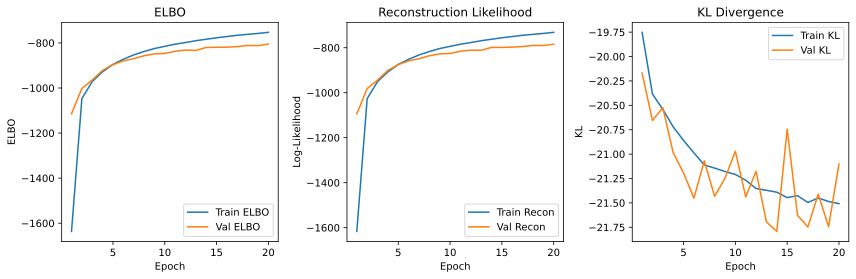

In [7]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, train_elbo, label='Train ELBO')
plt.plot(epochs_range, val_elbo, label='Val ELBO')
plt.title('ELBO')
plt.xlabel('Epoch')
plt.ylabel('ELBO')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_range, train_recon, label='Train Recon')
plt.plot(epochs_range, val_recon, label='Val Recon')
plt.title('Reconstruction Likelihood')
plt.xlabel('Epoch')
plt.ylabel('Log-Likelihood')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kl, label='Train KL')
plt.plot(epochs_range, val_kl, label='Val KL')
plt.title('KL Divergence')
plt.xlabel('Epoch')
plt.ylabel('KL')
plt.legend()

plt.tight_layout()
plt.show()


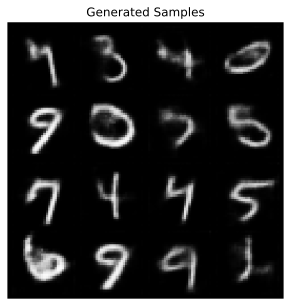

In [8]:
import torchvision.utils as vutils

with torch.no_grad():
    samples = model.sample(16)  # You can change the number of samples if desired

# Reshape if needed (e.g., [B, 1, 28, 28])
if samples.ndim == 2:  # [B, 784]
    samples = samples.view(-1, 1, 28, 28)

# Plot
plt.figure(figsize=(5, 5))
plt.axis("off")
plt.title("Generated Samples")
plt.imshow(
    vutils.make_grid(samples.cpu(), nrow=4, padding=2, normalize=True).permute(1, 2, 0)
)
plt.show()

A2

Digit 7 → 2


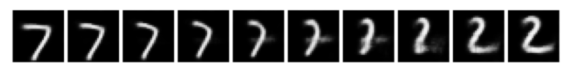

Digit 1 → 0


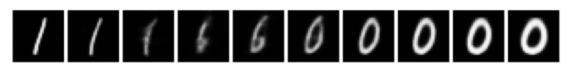

Digit 4 → 1


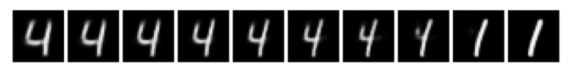

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision

def interpolate(model, img1, img2, steps=10):
    model.eval()
    with torch.no_grad():
        # Get z1 and z2 (use μ from q(z|x))
        # model.encode returns a tuple (mu, std)
        mu1_and_std1 = model.encode(img1.unsqueeze(0).to(device))
        mu1 = mu1_and_std1[0] # Get the mu tensor from the tuple
        mu1 = mu1.squeeze(0) # Squeeze the batch dimension (which is 1)

        mu2_and_std2 = model.encode(img2.unsqueeze(0).to(device))
        mu2 = mu2_and_std2[0] # Get the mu tensor from the tuple
        mu2 = mu2.squeeze(0) # Squeeze the batch dimension (which is 1)


        # Linear interpolation between z1 and z2
        # mu1 and mu2 are now shape [latent_dim]
        # z_path will be shape [steps, latent_dim] after stacking
        z_path = torch.stack([mu1 * (1 - t) + mu2 * t for t in torch.linspace(0, 1, steps)])

        # Decode each z to image
        reconstructions = model.decode(z_path).cpu()

        # Show all steps
        grid_img = torchvision.utils.make_grid(reconstructions, nrow=steps, pad_value=1)
        plt.figure(figsize=(steps, 1.5))
        # The output of make_grid will be [C, H, W]
        # The output from the decoder is expected to be [batch_size, C, H, W].
        # make_grid returns [C, H', W'], so we need to permute the dimensions.
        # Also, the output channel could be 1 (grayscale), so squeeze can remove that dimension for display.
        plt.imshow(grid_img.permute(1, 2, 0).squeeze(), cmap='gray')
        plt.axis('off')
        plt.show()

# Pick 3 pairs of different digits from test set
pairs = []
labels = []
# Ensure test_set is accessible, assuming it's defined in a previous cell
if 'test_set' not in globals():
    print("test_set not found. Please run the cell that loads the dataset.")
else:
    # Collect pairs from the test set
    collected_labels = []
    for img, label in test_set:
        if len(pairs) >= 6:
            break
        # Only add if the label hasn't been added twice already
        if collected_labels.count(label) < 2:
             pairs.append(img)
             labels.append(label)
             collected_labels.append(label)

    # Show interpolations
    if len(pairs) >= 6:
        for i in range(0, 6, 2):
            print(f"Digit {labels[i]} → {labels[i+1]}")
            interpolate(model, pairs[i], pairs[i+1])
    else:
        print(f"Could not collect 6 images with different digits. Only found {len(pairs)}.")